In [1]:
## Adopted from https://github.com/lindermanlab/ssm/blob/master/notebooks/4-Recurrent-SLDS.ipynb

import io
import os
import pickle
import sys
sys.path.insert(0, '/home/stonkszain/ed-stage-1/DISS/state-space-modelling/ssm-1')
sys.modules.pop('ssm', None)
sys.modules.pop('ssm.util', None)

# Set threading environment variables: prefer OpenMP for ssm C extensions,
# and limit BLAS to avoid nested parallelism.
import multiprocessing
n_cpus = multiprocessing.cpu_count()
os.environ['OMP_NUM_THREADS'] = str(n_cpus)
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['NUMBA_NUM_THREADS'] = str(n_cpus)

# Configure numba (if available)
try:
    import numba
    numba.set_num_threads(n_cpus)
    numba_available = True
except Exception:
    numba_available = False

import copy
import h5py

import scipy.io as sio
import autograd.numpy as np
import autograd.numpy.random as npr
npr.seed(12345)

import matplotlib.pyplot as plt
from matplotlib import gridspec
%matplotlib inline

import seaborn as sns
color_names = ["windows blue", "red", "amber", "faded green"]
colors = sns.xkcd_palette(color_names)
sns.set_style("white")
sns.set_context("talk")

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

import ssm
from ssm.util import random_rotation, find_permutation

mat = sio.loadmat('data/Refined_eat_drink_social_forNK.mat')

/home/stonkszain/ed-stage-1/DISS/state-space-modelling/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Benchmark cell intentionally left commented out.
# Uncomment to compare threading settings in a fresh kernel process or when debugging performance.
#
# ## Quick threading benchmark
# import time
# import numpy as onp
# import ctypes.util
# print('CPUs:', n_cpus)
# print('ENV OMP_NUM_THREADS:', os.environ.get('OMP_NUM_THREADS'))
# print('ENV MKL_NUM_THREADS:', os.environ.get('MKL_NUM_THREADS'))
# print('ENV OPENBLAS_NUM_THREADS:', os.environ.get('OPENBLAS_NUM_THREADS'))
# print('ctypes.find_library("gomp") ->', ctypes.util.find_library('gomp'))
# if numba_available:
#     import numba
#     print('numba threads:', numba.get_num_threads())
#     from numba import njit, prange
#
#     @njit(parallel=True)
#     def sum_squares(N):
#         s = 0.0
#         for i in prange(N):
#             s += (i % 100) ** 2
#         return s
#
#     t0 = time.time()
#     res = sum_squares(5000000)
#     t1 = time.time()
#     print('numba parallel time:', t1 - t0, 'res', res)
# else:
#     print('numba not available in kernel')
#
# A = onp.random.randn(1500, 1500)
# t0 = time.time()
# B = A.dot(A)
# t1 = time.time()
# print('BLAS matmul time:', t1 - t0)

In [3]:
# Helper functions
def plot_trajectory(z, x, ax=None, ls="-"):
    zcps = np.concatenate(([0], np.where(np.diff(z))[0] + 1, [z.size]))
    if ax is None:
        fig = plt.figure(figsize=(4, 4))
        ax = fig.gca()
    for start, stop in zip(zcps[:-1], zcps[1:]):
        ax.plot(x[start:stop + 1, 0],
                x[start:stop + 1, 1],
                lw=1, ls=ls,
                color=colors[z[start] % len(colors)],
                # color = "tab:gray",
                alpha = 1.0)
    ax.plot(x[-1, 0], x[-1, 1], 'ro', ms=5, alpha = 0.5)
    ax.plot(x[100, 0], x[100, 1], 'go', ms=5, alpha=0.8)
    return ax

def plot_observations(z, y, ax=None, ls="-", lw=1):
    zcps = np.concatenate(([0], np.where(np.diff(z))[0] + 1, [z.size]))
    if ax is None:
        fig = plt.figure(figsize=(4, 4))
        ax = fig.gca()
    T, N = y.shape
    t = np.arange(T)
    for n in range(N):
        for start, stop in zip(zcps[:-1], zcps[1:]):
            ax.plot(t[start:stop + 1], y[start:stop + 1, n],
                    lw=lw, ls=ls,
                    color=colors[z[start] % len(colors)],
                    alpha=1.0)
    return ax

def plot_most_likely_dynamics(model,
                              xlim=(-4,4), ylim=(-3,3), nxpts=20, nypts=20,
                              alpha=0.8, ax=None, figsize=(3, 3)):
    
    K = model.K
    assert model.D == 2
    x = np.linspace(*xlim, nxpts)
    y = np.linspace(*ylim, nypts)
    X, Y = np.meshgrid(x, y)
    xy = np.column_stack((X.ravel(), Y.ravel()))

    # Get the most likely state at each xy location
    logits = xy.dot(model.transitions.Rs.T) + model.transitions.r
    z = np.argmax(logits, axis=1)

    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111)

    for k, (A, b) in enumerate(zip(model.dynamics.As, model.dynamics.bs)):
        dxydt_m = xy.dot(A.T) + b - xy

        zk = z == k
        if np.any(zk):
            ax.quiver(xy[zk, 0], xy[zk, 1],
                      dxydt_m[zk, 0], dxydt_m[zk, 1],
                      color=colors[k % len(colors)], alpha=alpha
                    )
            
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

    plt.tight_layout()

    return ax


In [4]:
# Global parameters
T = 10000
K = 4
D_obs = 851
D_latent = 2

In [5]:
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'M1_drink', 'M1_eat', 'M1_eat1', 'M1_eat3', 'M1_eat3_pel', 'M1_social', 'M1_social_long', 'M1_social_short', 'M2_drink', 'M2_eat', 'M2_eat1', 'M2_eat3', 'M2_eat3_pel', 'M2_social', 'M2_social_long', 'M2_social_short', 'note'])

In [6]:
mat['M1_eat'].shape

(851, 401, 23)

In [7]:
M1_data = np.einsum('nti -> itn',mat['M1_eat'])
M1_data.shape

(23, 401, 851)

In [8]:
M2_data = np.einsum('nti -> itn',mat['M2_eat'])
M2_data.shape

(41, 401, 505)

In [9]:
# datas = [M1_data[i] for i in range(M1_data.shape[0])]

In [10]:
# datas.shape

In [11]:
# rslds = ssm.SLDS(D_obs, K, D_latent,
#                  transitions='recurrent_only',
#                  dynamics='diagonal_gaussian',
#                  emissions='gaussian_orthog',
#                  single_subspace=True)
# rslds.initialize(datas)



In [12]:
# q_elbos_lem, q_lem = rslds.fit(datas,
#                                method="laplace_em",
#                                variational_posterior="structured_meanfield",
#                                initialize=False, num_iters=10, alpha=0.0)



In [13]:
# q_elbos_lem

In [14]:
# # Convergence check
# sns.lineplot(q_elbos_lem[1:])

In [15]:
# xhat_lem = np.mean(q_lem.mean_continuous_states, axis=1)
# # rslds.permute(find_permutation(z, rslds.most_likely_states(xhat_lem, datas)))
# # zhat_lem = rslds.most_likely_states(xhat_lem, datas)

# rslds_lem = copy.deepcopy(rslds)

In [16]:
# plt.figure(figsize=(6,4))
# ax = plt.subplot(111)
# lim = abs(xhat_lem).max(axis=0) + 1
# plot_most_likely_dynamics(rslds_lem, xlim=(-lim[0], lim[0]), ylim=(-lim[1], lim[1]), ax=ax)
# plt.title("Inferred Dynamics, Laplace-EM")

In [17]:
# xhat_lem

In [18]:
def run_ssm_experiments(data,
                        slds_T=1000,
                        slds_K=4,
                        slds_D_latent=2,
                        slds_transitions="recurrent_only",
                        slds_dynamics="diagonal_gaussian",
                        slds_emissions="gaussian_orthog",
                        slds_single_subspace=True,
                        fit_method="laplace_em",
                        fit_variational_posterior="structured_meanfield",
                        fit_initialize=False,
                        fit_num_iters=100,
                        fit_alpha=0.0,
                        cv=False,
                        cv_folds=5,
                        cv_context=150,
                        cv_horizon=401):
    datas = [data[i] for i in range(data.shape[0])]
    
    if cv:
        kf = KFold(n_splits=cv_folds, shuffle=True, random_state=127)
        fold_score = []

        for train_idx, test_idx in kf.split(datas):
            train_datas = [datas[i] for i in train_idx]
            test_datas = [datas[i] for i in test_idx]

            rslds = ssm.SLDS(data.shape[2], slds_K, slds_D_latent,
                        transitions=slds_transitions,
                        dynamics=slds_dynamics,
                        emissions=slds_emissions,
                        single_subspace=slds_single_subspace)
            
            rslds.initialize(train_datas)
            rslds.fit(train_datas, method=fit_method, variational_posterior=fit_variational_posterior, initialize=fit_initialize, num_iters=fit_num_iters, alpha=fit_alpha)

            _, q_test = rslds.approximate_posterior()
            
        pass
        
    else:
        rslds = ssm.SLDS(data.shape[2], slds_K, slds_D_latent,
                        transitions=slds_transitions,
                        dynamics=slds_dynamics,
                        emissions=slds_emissions,
                        single_subspace=slds_single_subspace)
        rslds.initialize(datas)

        q_elbos, q = rslds.fit(datas,
                            method=fit_method,
                            variational_posterior=fit_variational_posterior,
                            initialize=fit_initialize,
                            num_iters=fit_num_iters,
                            alpha=fit_alpha)
        
        # Convergence check
        sns.lineplot(q_elbos[1:])

        # print(len(datas))
        example_trial_index = np.random.choice(range(len(datas)))
        # print(example_trial_index)
        xhat = q.mean_continuous_states[example_trial_index]
        xhat_mean = np.mean(q.mean_continuous_states, axis=1)
        zhat = rslds.most_likely_states(xhat, datas[example_trial_index])

        rslds = copy.deepcopy(rslds)

        plt.figure(figsize=(6,4))
        ax = plt.subplot(111)
        lim = abs(xhat_mean).max(axis=0) + 1
        plot_most_likely_dynamics(rslds, xlim=(-lim[0],lim[0]), ylim=(-lim[1],lim[1]), ax=ax)
        
        plot_trajectory(zhat, xhat, ax=ax)
        plt.title("Inferred Dynamics")

## Run different fitting experiments for the dynamics type and fit method.

### Dynamics tests

In [19]:
# run_ssm_experiments(data=M1_data, fit_num_iters=100, slds_dynamics="gaussian")

In [20]:
# run_ssm_experiments(data=M1_data, fit_num_iters=100, slds_dynamics="diagonal_gaussian")

In [21]:
# run_ssm_experiments(data=M1_data, fit_num_iters=100, slds_dynamics="studentst")

In [22]:
# run_ssm_experiments(data=M1_data, fit_num_iters=100, slds_dynamics="diagonal_t")

### Fit method

In [23]:
# run_ssm_experiments(data=M1_data, fit_num_iters=100, fit_method="laplace_em")

In [24]:
# run_ssm_experiments(data=M1_data, fit_num_iters=100, fit_method="bbvi", fit_variational_posterior="meanfield")

ELBO: -8667425.8: 100%|██████████| 2000/2000 [2:39:47<00:00,  4.79s/it]  


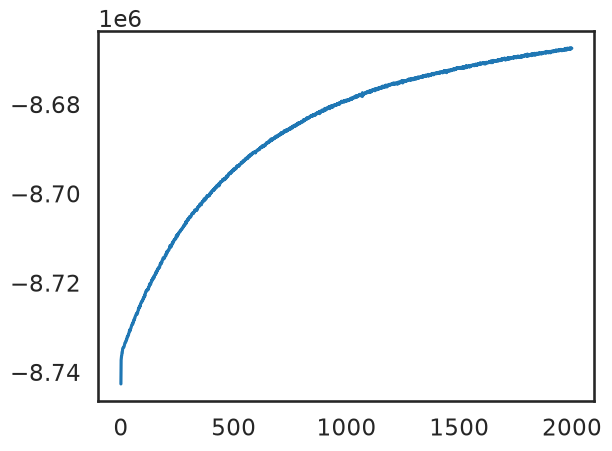

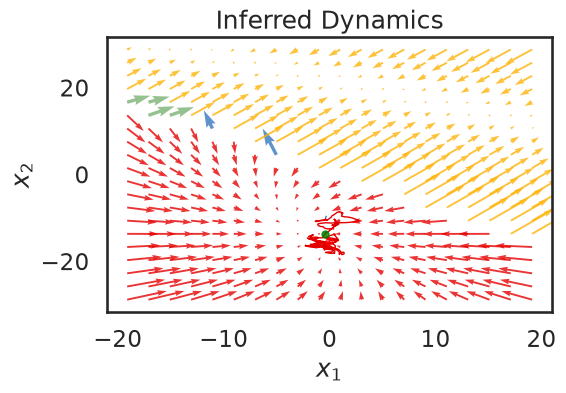

In [25]:
# Run on M1 eat

run_ssm_experiments(data=M1_data, fit_num_iters=2000)

ELBO: -9459977.3: 100%|██████████| 100/100 [08:55<00:00,  5.35s/it]


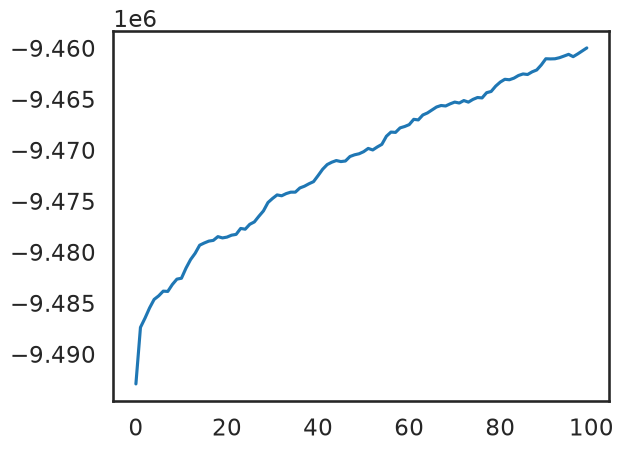

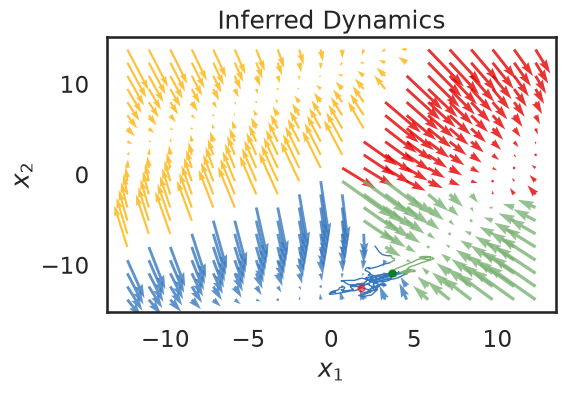

In [26]:
# Run on M2 eat

run_ssm_experiments(data=M2_data, fit_num_iters=100)

ELBO: -4303408.4: 100%|██████████| 100/100 [04:06<00:00,  2.46s/it]


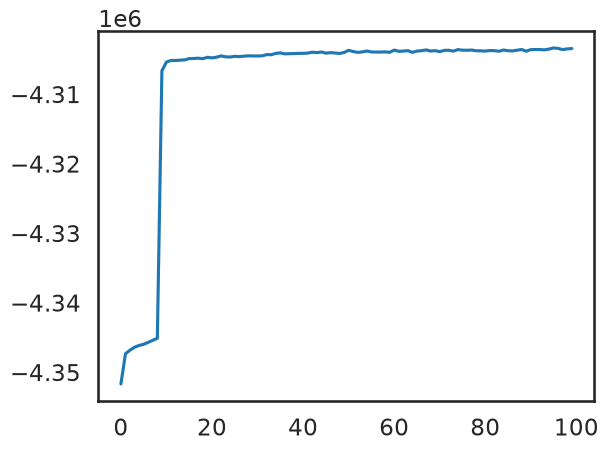

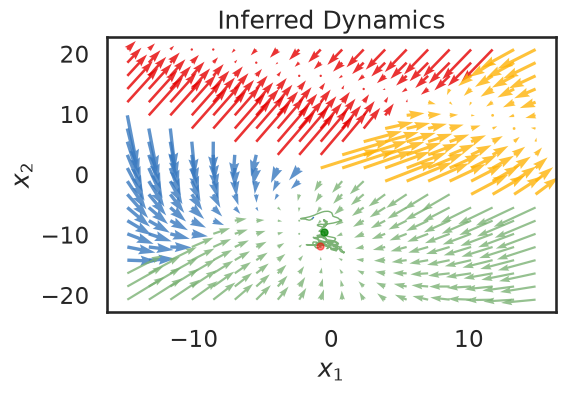

In [27]:
# Run on M1 eat odd

M1_eat_odd = M1_data[:,:,::2]

run_ssm_experiments(data = M1_eat_odd, fit_num_iters=100)

ELBO: -4374712.6: 100%|██████████| 100/100 [04:13<00:00,  2.53s/it]


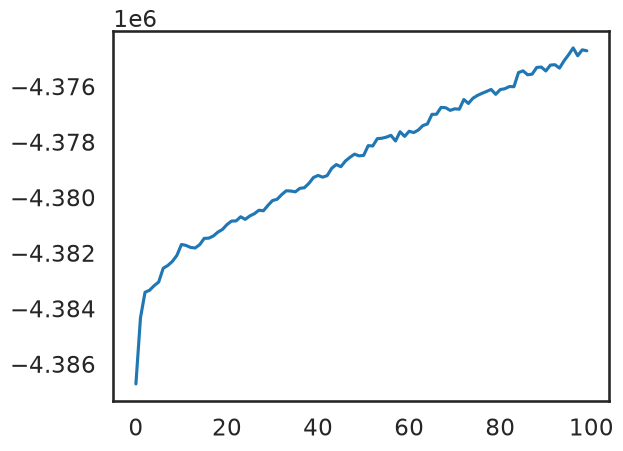

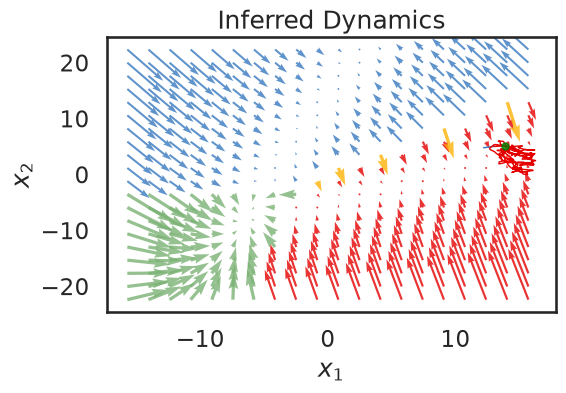

In [28]:
# Run on M1 eat even

M1_eat_even = M1_data[:,:,1::2]

run_ssm_experiments(data = M1_eat_even, fit_num_iters=100)

ELBO: -2154917.4: 100%|██████████| 1000/1000 [22:35<00:00,  1.36s/it]


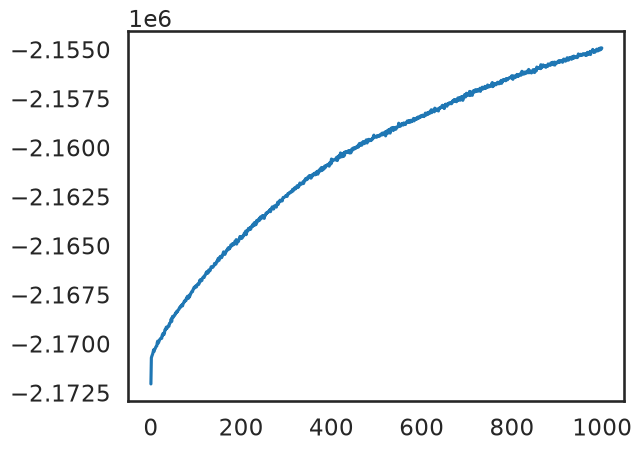

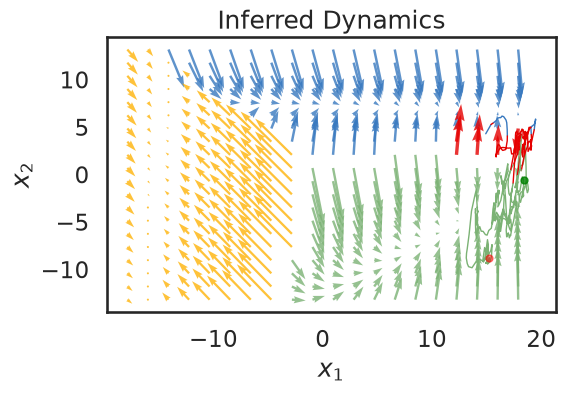

In [29]:
M1_drink = np.einsum('nti -> itn', mat['M1_drink'])

run_ssm_experiments(data=M1_drink, fit_num_iters=1000)

ELBO: -4130228.8: 100%|██████████| 100/100 [03:45<00:00,  2.26s/it]


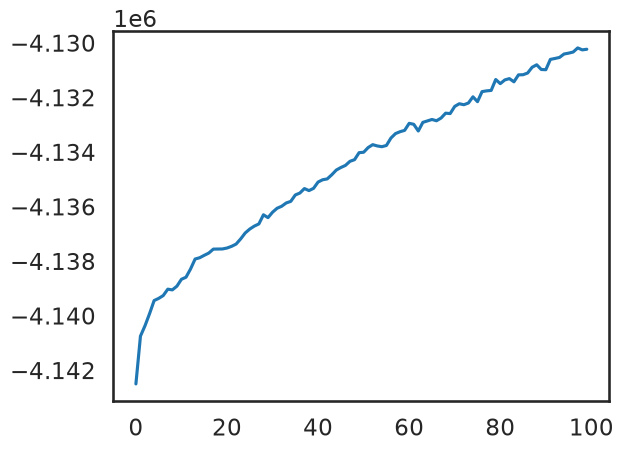

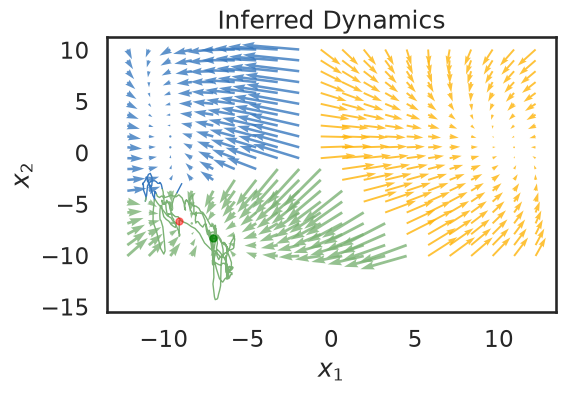

In [30]:
M2_drink = np.einsum('nti -> itn', mat['M2_drink'])

run_ssm_experiments(data=M2_drink, fit_num_iters=100)

ELBO: -7077035.1: 100%|██████████| 1000/1000 [1:05:55<00:00,  3.96s/it]


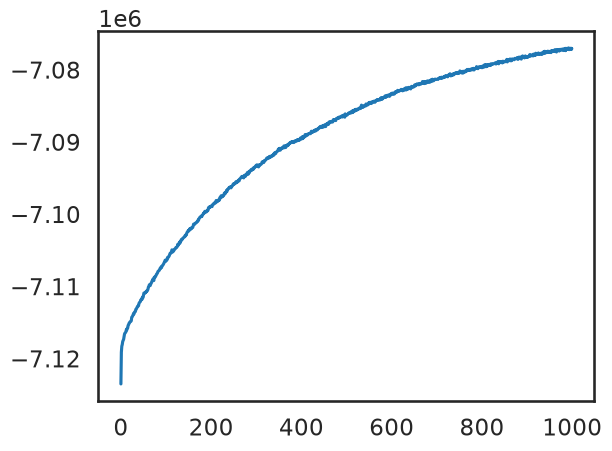

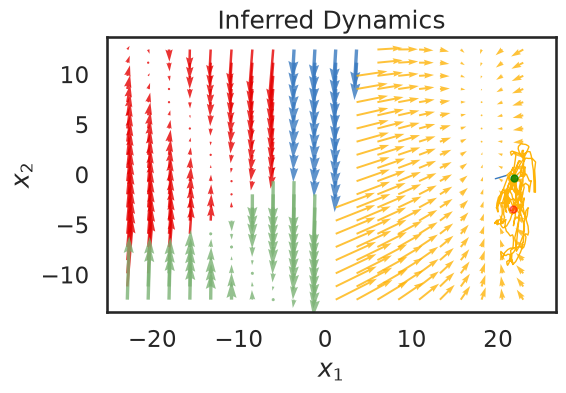

In [31]:
M1_social = np.einsum('nti -> itn', mat['M1_social'])

run_ssm_experiments(data = M1_social, fit_num_iters=1000)

In [32]:
with h5py.File('data/processed_data_no_social.h5', 'r') as f:
    # g04_eat = f['g04']['eat'][:]
    g04_eat = np.einsum('nti -> itn', f['g04']['eat'][:])
    g04_drink = np.einsum('nti -> itn', f['g04']['drink'][:])
    g06_eat = np.einsum('nti -> itn', f['g06']['eat'][:])


g04_eat.shape

(18, 401, 29)

ELBO: -132022.6: 100%|██████████| 1000/1000 [12:49<00:00,  1.30it/s]


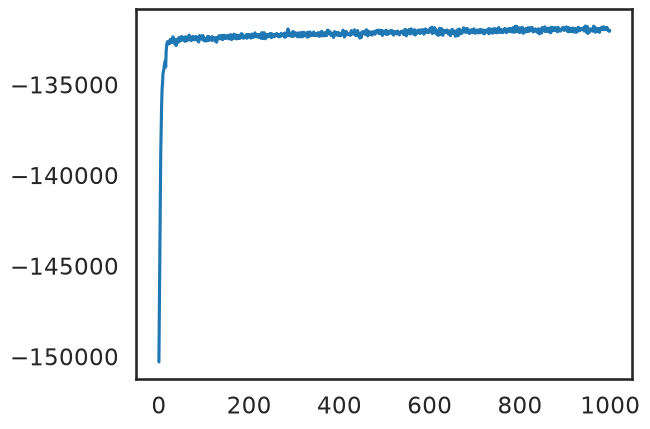

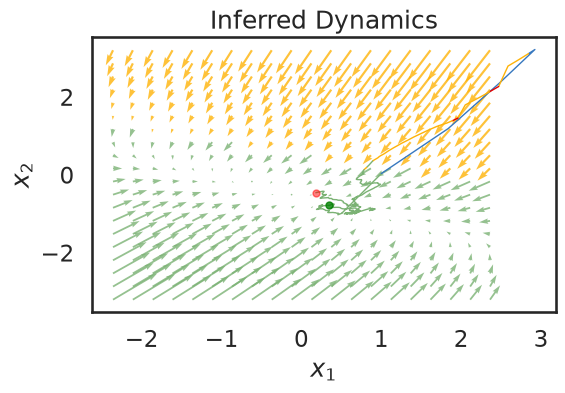

In [33]:
# Train on g04 eat data


run_ssm_experiments(data = g04_eat, fit_num_iters=1000, slds_K=4)

ELBO: -69295.9: 100%|██████████| 500/500 [06:08<00:00,  1.36it/s]


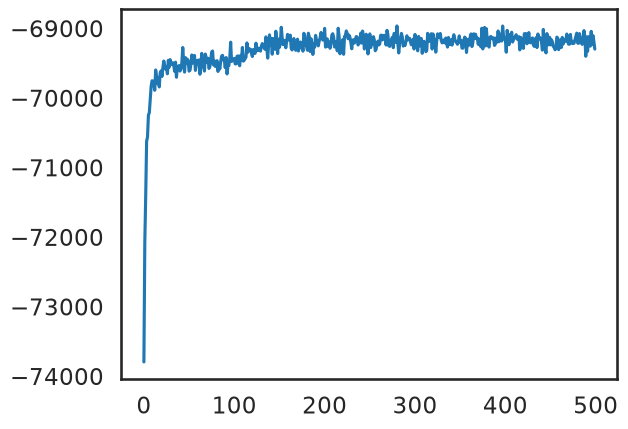

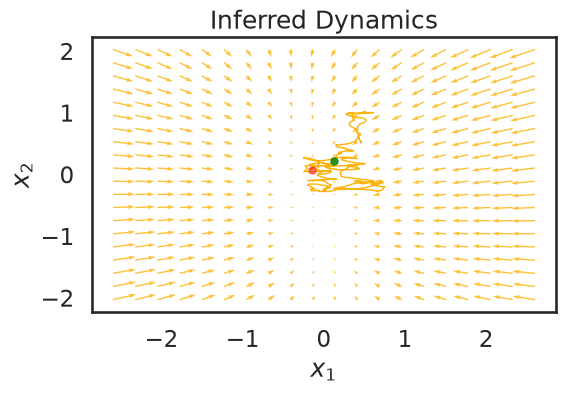

In [34]:
# Train on g04 odd

g04_eat_odd = g04_eat[:, :, ::2]

run_ssm_experiments(data=g04_eat_odd, fit_num_iters=500)

ELBO: -54963.2: 100%|██████████| 500/500 [06:03<00:00,  1.37it/s]


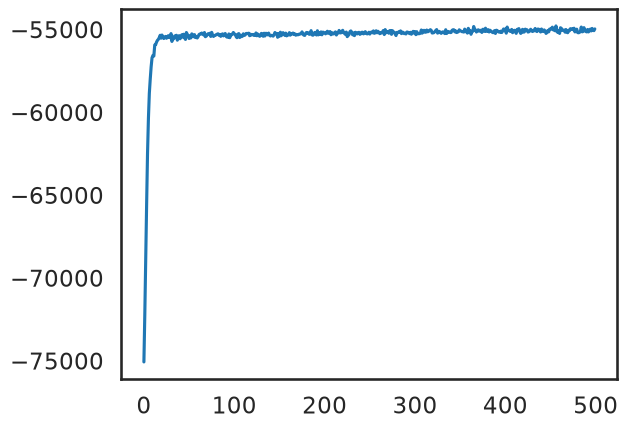

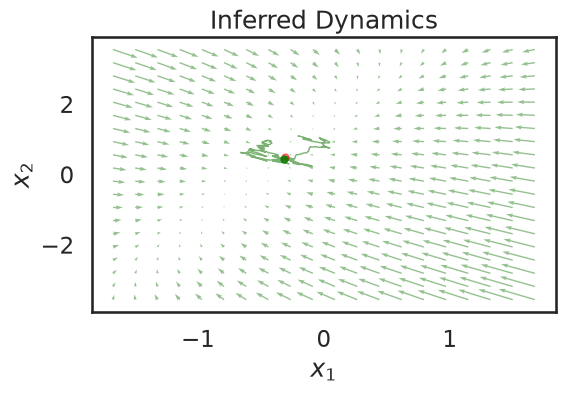

In [35]:
# Train on g04 even

g04_eat_even = g04_eat[:, :, 1::2]

run_ssm_experiments(data=g04_eat_even, fit_num_iters=500)

ELBO: -84404.3: 100%|██████████| 500/500 [04:55<00:00,  1.69it/s]


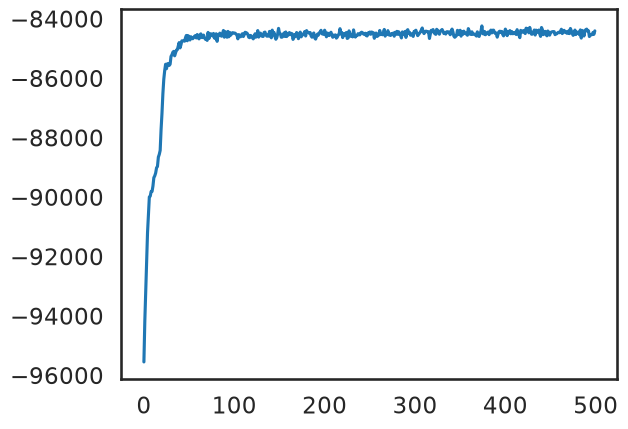

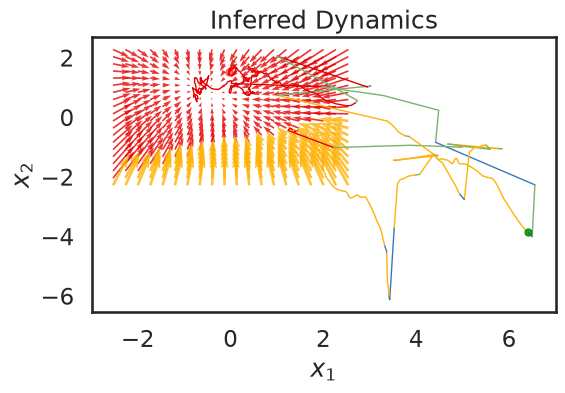

In [36]:
# Train on g06 eat data

run_ssm_experiments(data=g06_eat, fit_num_iters=500, slds_K=4) 

ELBO: -37166.8: 100%|██████████| 500/500 [02:29<00:00,  3.34it/s]


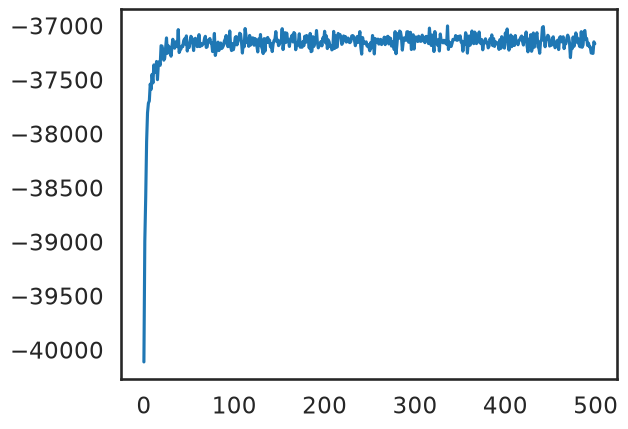

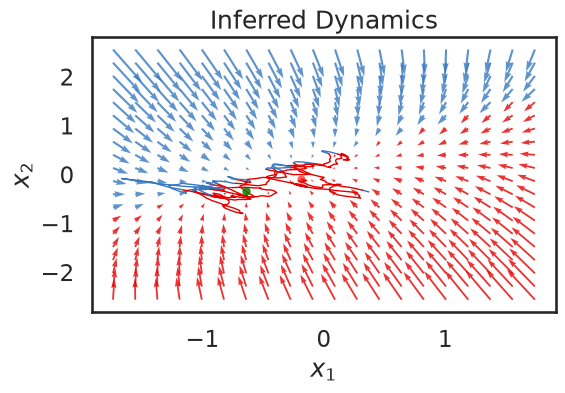

In [37]:
# Train on g04 drink data

run_ssm_experiments(data=g04_drink, fit_num_iters=500, slds_K=4) 

In [38]:
# # Global parameters
# T = 10000
# K = 4
# D_obs = M2_data.shape[2]
# D_latent = 2

# datas = [M2_data[i] for i in range(M2_data.shape[0])]

# rslds = ssm.SLDS(D_obs, K, D_latent,
#                  transitions='recurrent_only',
#                  dynamics='diagonal_gaussian',
#                  emissions='gaussian_orthog',
#                  single_subspace=True)
# rslds.initialize(datas)

# q_elbos_lem, q_lem = rslds.fit(datas,
#                                method="laplace_em",
#                                variational_posterior="structured_meanfield",
#                                initialize=False, num_iters=10, alpha=0.0)

# # Convergence check
# sns.lineplot(q_elbos_lem[1:])

# xhat_lem = np.mean(q_lem.mean_continuous_states, axis=1)
# # rslds.permute(find_permutation(z, rslds.most_likely_states(xhat_lem, datas)))
# # zhat_lem = rslds.most_likely_states(xhat_lem, datas)

# rslds_lem = copy.deepcopy(rslds)

# plt.figure(figsize=(6,4))
# ax = plt.subplot(111)
# lim = abs(xhat_lem).max(axis=0) + 1
# plot_most_likely_dynamics(rslds_lem, xlim=(-lim[0], lim[0]), ylim=(-lim[1], lim[1]), ax=ax)
# plt.title("Inferred Dynamics, Laplace-EM")

In [39]:
# M1_data[:, :, ::2].shape

In [40]:
# run_ssm_experiments(data = M1_data, fit_num_iters=200)